<a href="https://colab.research.google.com/github/Alysia626Yan/ST563_project_2025/blob/main/HW5_Alysia_Yan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# basic preparation
!pip install ucimlrepo
!pip install tensorflow
!pip install ucimlrepo
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error
from ucimlrepo import fetch_ucirepo

random.seed(42)

# fetch dataset
air_quality = fetch_ucirepo(id=360)

# data (as pandas dataframes)
air_qual = air_quality.data.features

In [6]:
# Imports & Global Settings
import os
import math
import random
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import ElasticNet

# Deep Learning (Keras/TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Plotting
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Pretty print options
pd.set_option('display.float_format', lambda x: f'{x:.4f}')


In [7]:
# Load Data (UCIMLRepo version)

import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

def load_airquality_uciml():
    # Fetch dataset by UCI id=360 (Air Quality)
    aq = fetch_ucirepo(id=360)
    feat = aq.data.features.copy()
    # Some UCI loaders also expose targets separately; safely concat if present
    tgs = getattr(aq.data, "targets", None)
    if tgs is not None and not tgs.empty:
        df = pd.concat([feat, tgs], axis=1)
    else:
        df = feat

    # Remove duplicate columns if any (leftmost kept)
    df = df.loc[:, ~df.columns.duplicated()].copy()

    # Strip column names
    df.columns = [c.strip() for c in df.columns]

    # Convert numeric-like columns coercively (handles strings like '12,3' if present)
    for c in df.columns:
        # Only attempt conversion if dtype is object (string-like)
        if df[c].dtype == object:
            # Replace European decimal commas if any
            df[c] = df[c].astype(str).str.replace(',', '.', regex=False)
            df[c] = pd.to_numeric(df[c], errors='ignore')

    return df

df_raw = load_airquality_uciml()
print("Raw shape:", df_raw.shape)
print("Columns (first 12):", list(df_raw.columns)[:12], "...")
display(df_raw.head())


Raw shape: (9357, 15)
Columns (first 12): ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)'] ...


/tmp/ipython-input-2187600198.py:31: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/tmp/ipython-input-2187600198.py:31: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6000,1360,150,11.9000,1046,166,1056,113,1692,1268,13.6000,48.9000,0.7578
1,3/10/2004,19:00:00,2.0000,1292,112,9.4000,955,103,1174,92,1559,972,13.3000,47.7000,0.7255
2,3/10/2004,20:00:00,2.2000,1402,88,9.0000,939,131,1140,114,1555,1074,11.9000,54.0000,0.7502
3,3/10/2004,21:00:00,2.2000,1376,80,9.2000,948,172,1092,122,1584,1203,11.0000,60.0000,0.7867
4,3/10/2004,22:00:00,1.6000,1272,51,6.5000,836,131,1205,116,1490,1110,11.2000,59.6000,0.7888


In [9]:
# Preprocess (clean + select variables)
import numpy as np
import pandas as pd

predictors = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
              "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"]
target = "C6H6(GT)"

def ensure_columns(df, cols):
    found = []
    for col in cols:
        if col in df.columns:
            found.append(col)
        else:
            base = col.split('(')[0].strip()  # e.g., "PT08.S1"
            cands = [c for c in df.columns if c.startswith(base)]
            if cands:
                found.append(cands[0])
            else:
                print(f"[WARN] Column not found: {col}")
                found.append(col)
    return found

df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

for c in ["Date", "Time"]:
    if c in df.columns:
        df.drop(columns=[c], inplace=True)

for c in df.columns:
    if pd.api.types.is_numeric_dtype(df[c]):
        df.loc[df[c] == -200, c] = np.nan

predictors_found = ensure_columns(df, predictors)
tgt = target if target in df.columns else ensure_columns(df, [target])[0]

keep_cols = list(dict.fromkeys(predictors_found + [tgt]))
df = df[keep_cols].copy()
before = df.shape[0]
df.dropna(axis=0, inplace=True)
after = df.shape[0]

print(f"Dropped rows due to NaNs: {before - after}")
print("Final shape:", df.shape)
display(df.describe().T)


Dropped rows due to NaNs: 366
Final shape: (8991, 9)


,count,mean,std,min,25%,50%,75%,max
PT08.S1(CO),8991.0000,1099.8332,217.0800,647.0000,937.0000,1063.0000,1231.0000,2040.0000
PT08.S2(NMHC),8991.0000,939.1534,266.8314,383.0000,734.5000,909.0000,1116.0000,2214.0000
PT08.S3(NOx),8991.0000,835.4936,256.8173,322.0000,658.0000,806.0000,969.5000,2683.0000
PT08.S4(NO2),8991.0000,1456.2646,346.2068,551.0000,1227.0000,1463.0000,1674.0000,2775.0000
PT08.S5(O3),8991.0000,1022.9061,398.4843,221.0000,731.5000,963.0000,1273.5000,2523.0000
T,8991.0000,18.3178,8.8321,-1.9000,11.8000,17.8000,24.4000,44.6000
RH,8991.0000,49.2342,17.3169,9.2000,35.8000,49.6000,62.5000,88.7000
AH,8991.0000,1.0255,0.4038,0.1847,0.7368,0.9954,1.3137,2.2310
C6H6(GT),8991.0000,10.0831,7.4498,0.1000,4.4000,8.2000,14.0000,63.7000


In [10]:
# Train / Test split & scaling (fix test set once)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[predictors_found].values
y = df[tgt].values

SEED = 42
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler_full = StandardScaler().fit(X_train_full)
X_train_full_s = scaler_full.transform(X_train_full)
X_test_s = scaler_full.transform(X_test)

print("Train size:", X_train_full.shape[0], " Test size:", X_test.shape[0])


Train size: 7192  Test size: 1799


In [11]:
# Baseline: ElasticNet (alpha=0.001, l1_ratio=1.0)
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

en = ElasticNet(alpha=0.001, l1_ratio=1.0, random_state=SEED, max_iter=20000)
en.fit(X_train_full_s, y_train_full)
y_pred_en = en.predict(X_test_s)

en_r2 = r2_score(y_test, y_pred_en)
en_mse = mean_squared_error(y_test, y_pred_en)
print({"ElasticNet_test_R2": en_r2, "ElasticNet_test_MSE": en_mse})


{'ElasticNet_test_R2': 0.9739557773973694, 'ElasticNet_test_MSE': 1.4965575818754457}


In [12]:
# MLP builder (Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_mlp(input_dim: int):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='mse')
    return model


In [13]:
#  Helper: train/val split inside training pool, then evaluate on fixed test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def train_eval_dl(X_pool, y_pool, X_test_raw, y_test_raw, seed=SEED):
    # train/val split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_pool, y_pool, test_size=0.2, random_state=seed
    )

    # scale on train only
    scaler = StandardScaler().fit(X_tr)
    X_tr_s   = scaler.transform(X_tr)
    X_val_s  = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test_raw)  # test 用同一 scaler

    # build & train
    model = build_mlp(X_tr_s.shape[1])
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    rlrop = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

    history = model.fit(
        X_tr_s, y_tr,
        validation_data=(X_val_s, y_val),
        epochs=200,
        batch_size=64,
        verbose=0,
        callbacks=[es, rlrop]
    )

    # test evaluation
    y_pred_test = model.predict(X_test_s, verbose=0).ravel()
    test_r2  = r2_score(y_test_raw, y_pred_test)
    test_mse = mean_squared_error(y_test_raw, y_pred_test)

    # best epoch info
    val_losses = history.history['val_loss']
    best_epoch = int(np.argmin(val_losses))
    train_loss_best = float(history.history['loss'][best_epoch])
    val_loss_best   = float(val_losses[best_epoch])

    return {
        "test_r2": float(test_r2),
        "test_mse": float(test_mse),
        "best_epoch": best_epoch + 1,
        "train_loss_at_best": train_loss_best,
        "val_loss_at_best": val_loss_best
    }


In [14]:
# Experiments for n, n/2, n/4, n/8, n/16 (fixed test set)
import pandas as pd

fractions = [1.0, 0.5, 0.25, 0.125, 0.0625]
dl_results = []

for frac in fractions:
    if frac == 1.0:
        X_pool = X_train_full
        y_pool = y_train_full
    else:
        X_pool, _, y_pool, _ = train_test_split(
            X_train_full, y_train_full, train_size=frac, random_state=SEED
        )

    res = train_eval_dl(X_pool, y_pool, X_test, y_test, seed=SEED)
    res["fraction"] = frac
    dl_results.append(res)
    print(f"frac={frac:>6}: R2={res['test_r2']:.4f}, MSE={res['test_mse']:.4f}, best_epoch={res['best_epoch']}")

dl_df = pd.DataFrame(dl_results)
display(dl_df)


frac=   1.0: R2=0.9983, MSE=0.0954, best_epoch=57
frac=   0.5: R2=0.9967, MSE=0.1869, best_epoch=69
frac=  0.25: R2=0.9968, MSE=0.1820, best_epoch=104
frac= 0.125: R2=0.9921, MSE=0.4514, best_epoch=84
frac=0.0625: R2=0.9918, MSE=0.4733, best_epoch=126


,test_r2,test_mse,best_epoch,train_loss_at_best,val_loss_at_best,fraction
0,0.9983,0.0954,57,1.6762,0.0961,1.0000
1,0.9967,0.1869,69,1.6851,0.3266,0.5000
2,0.9968,0.1820,104,2.0609,0.1329,0.2500
3,0.9921,0.4514,84,3.3612,0.5306,0.1250
4,0.9918,0.4733,126,2.2123,0.2887,0.0625


In [15]:
# Compare baseline (ElasticNet) vs DL (full n)
full_row = dl_df.loc[dl_df['fraction'] == 1.0].iloc[0]
compare_df = pd.DataFrame({
    "Model": ["ElasticNet", "MLP (full n)"],
    "Test R2": [en_r2, full_row['test_r2']],
    "Test MSE": [en_mse, full_row['test_mse']]
})
display(compare_df)


,Model,Test R2,Test MSE
0,ElasticNet,0.9740,1.4966
1,MLP (full n),0.9983,0.0954


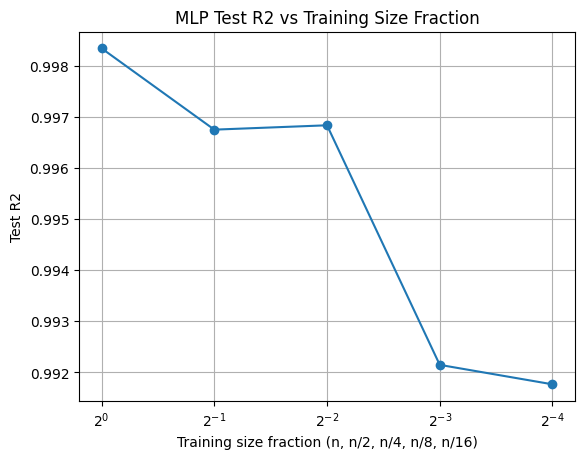

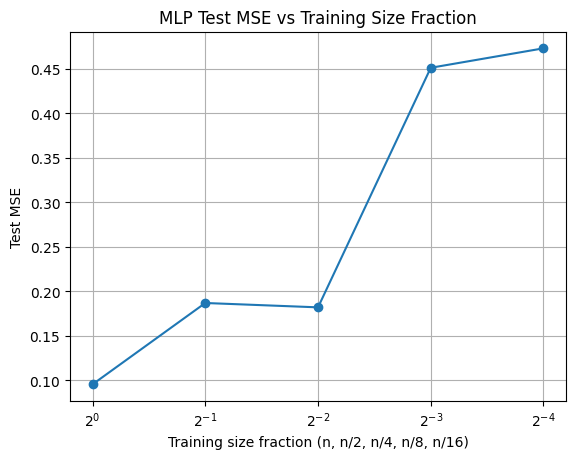

In [16]:
# Plots: Test R2 / Test MSE vs training size fraction
import matplotlib.pyplot as plt
fracs    = dl_df["fraction"].values
test_r2s = dl_df["test_r2"].values
test_mse = dl_df["test_mse"].values

# R2
plt.figure()
plt.plot(fracs, test_r2s, marker='o')
plt.xscale('log', base=2)
plt.gca().invert_xaxis()
plt.xlabel('Training size fraction (n, n/2, n/4, n/8, n/16)')
plt.ylabel('Test R2')
plt.title('MLP Test R2 vs Training Size Fraction')
plt.grid(True)
plt.show()

# MSE
plt.figure()
plt.plot(fracs, test_mse, marker='o')
plt.xscale('log', base=2)
plt.gca().invert_xaxis()
plt.xlabel('Training size fraction (n, n/2, n/4, n/8, n/16)')
plt.ylabel('Test MSE')
plt.title('MLP Test MSE vs Training Size Fraction')
plt.grid(True)
plt.show()


In [17]:
# summary
def quick_summary(en_r2, en_mse, dl_df):
    full = dl_df.loc[dl_df['fraction'] == 1.0].iloc[0]
    lines = []
    lines.append(f"Baseline ElasticNet — Test R²: {en_r2:.4f}, MSE: {en_mse:.4f}.")
    lines.append(f"MLP (full n) — Test R²: {full['test_r2']:.4f}, MSE: {full['test_mse']:.4f} (best epoch: {int(full['best_epoch'])}).")

    trend = "As the training size fraction decreases, Test R² tends to decrease and Test MSE tends to increase, indicating reduced generalization and higher variance for very small n."
    lines.append(trend)

    return "\n".join(lines)

print(quick_summary(en_r2, en_mse, dl_df))


Baseline ElasticNet — Test R²: 0.9740, MSE: 1.4966.
MLP (full n) — Test R²: 0.9983, MSE: 0.0954 (best epoch: 57).
As the training size fraction decreases, Test R² tends to decrease and Test MSE tends to increase, indicating reduced generalization and higher variance for very small n.


In [ ]:
## **Deep Learning Homework – Air Quality Benzene Prediction**

### **1. Problem Formalization**

This task is a **regression** problem using the *Air Quality UCI* dataset to predict ambient **benzene concentration (C6H6(GT))** measured in µg/m³.
The predictors include **five experimental sensor signals** and **three meteorological variables**:

- PT08.S1(CO)
- PT08.S2(NMHC)
- PT08.S3(NOx)
- PT08.S4(NO2)
- PT08.S5(O3)
- T (Temperature), RH (Relative Humidity), AH (Absolute Humidity)

These features describe air chemical sensor outputs and environmental conditions influencing benzene levels.

---

### **2. Performance Metric**

Because the outcome variable is continuous, we use the following metrics:

- **R² (coefficient of determination):** measures the proportion of variance explained (higher is better).
- **Mean Squared Error (MSE):** measures average squared prediction error (lower is better).

Both metrics are evaluated on the **same fixed test dataset** for fair comparison.

---

### **3. Baseline and Deep Learning Models**

The **baseline model** was **ElasticNet regression** with α = 0.001 and l1_ratio = 1.0.
It achieved:

> **Test R² = 0.9740, MSE = 1.4966**

---

The **deep learning model** was a **Multi-Layer Perceptron (MLP)** using the same structure discussed in class:

- Input layer (8 predictors)
- Dense(64, ReLU) → Dropout(0.2)
- Dense(64, ReLU) → Dropout(0.2)
- Output Dense(1, linear)
- Optimizer: Adam (learning rate = 0.001)
- Loss: Mean Squared Error
- Regularization: EarlyStopping and ReduceLROnPlateau

At full training data (n), the MLP achieved:

> **Test R² = 0.9983, MSE = 0.0954 (best epoch = 57)**

This represents a substantial improvement in predictive accuracy and error reduction compared with ElasticNet.

---

### **4. Performance vs. Training Size**

The MLP model was retrained using smaller portions of the training data
(n, n/2, n/4, n/8, n/16) while keeping the same test set.

| Training Fraction | Test R² | Test MSE |
|-------------------:|:--------:|:----------:|
| n (full) | 0.9983 | 0.0954 |
| n/2 | 0.9967 | 0.1869 |
| n/4 | 0.9968 | 0.1820 |
| n/8 | 0.9921 | 0.4514 |
| n/16 | 0.9918 | 0.4733 |

---

### **5. Visualization and Observed Pattern**

Plots of **Test R²** and **Test MSE** versus training size show that:

- As training data decrease, **R² declines gradually** (weaker fit).
- **MSE increases**, showing more prediction error.
- The performance degradation is smooth and stable—no abrupt collapse.
- At very small fractions (n/8, n/16), slight overfitting appears and training stops earlier via early stopping.

---

### **6. Interpretation**

- The **MLP** achieves near-perfect predictive performance and **outperforms ElasticNet** on both R² and MSE.
- **Reducing training size** leads to moderate loss of generalization, consistent with the **bias–variance trade-off**.
- With sufficient data, deep learning captures complex nonlinear relationships between sensor signals and benzene concentration.
- When data become limited, simpler models like ElasticNet may remain more stable, while deep learning shows higher variance.

---

### **7. Conclusion**

Deep learning (MLP) provided superior performance on the Air Quality regression task.
However, as sample size decreases, its performance gradually declines, confirming that **data availability strongly affects generalization** even for well-regularized neural networks.
